In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


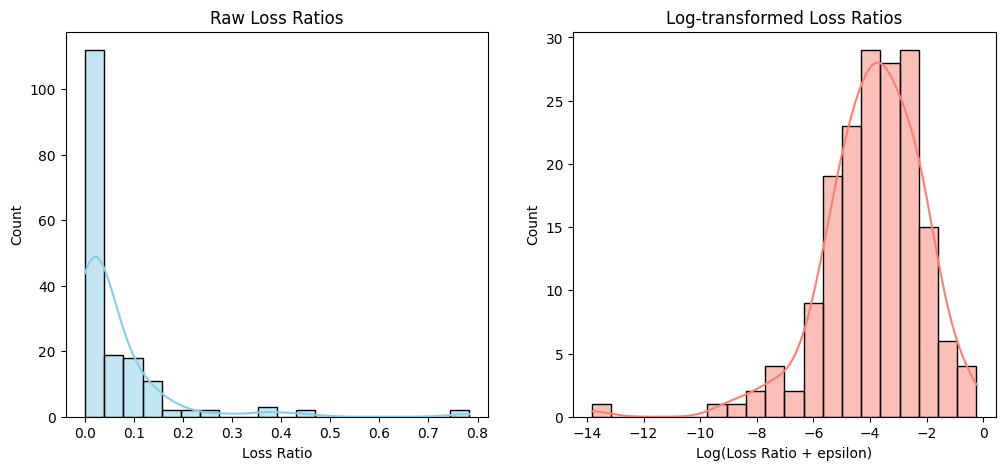

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

loss_ratios = pd.to_numeric(y_series, errors='coerce')

epsilon = 1e-6
log_losses = np.log(loss_ratios + epsilon)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(loss_ratios, bins=20, kde=True, color='skyblue')
plt.title("Raw Loss Ratios")
plt.xlabel("Loss Ratio")

plt.subplot(1,2,2)
sns.histplot(log_losses, bins=20, kde=True, color='salmon')
plt.title("Log-transformed Loss Ratios")
plt.xlabel("Log(Loss Ratio + epsilon)")

plt.show()


In [36]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.metrics import mean_squared_error
import joblib

X_train = pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/X_train.pkl')
y_train = pd.to_numeric(
    pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/y_train.pkl'),
    errors='coerce'
)

X_val = pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/X_validation.pkl')
y_val = pd.to_numeric(
    pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/y_validation.pkl'),
    errors='coerce'
)

X_test = pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/X_test.pkl')
y_test = pd.to_numeric(
    pd.read_pickle('/content/drive/My Drive/CS229/GMM Model Folder/For_Model/y_test.pkl'),
    errors='coerce'
)

X_unlabeled = pd.read_pickle(
    '/content/drive/My Drive/CS229/GMM Model Folder/For_Model/X_unlabelled.pkl'
)

epsilon = 1e-6
y_train_log = np.log(y_train + epsilon)
y_val_log = np.log(y_val + epsilon)
y_test_log = np.log(y_test + epsilon)

def semi_supervised_gmm(
    X_train, y_train_log,
    X_unlabeled,
    X_val, y_val_log,
    K,
    max_iter=10,
    unlabeled_batch_size=200_000,
    tol=1e-4
):
    X_train_np = X_train.to_numpy()
    X_unlabeled_np = X_unlabeled.to_numpy()
    X_val_np = X_val.to_numpy()

    N_labeled = len(X_train_np)
    D = X_train_np.shape[1]

    quantiles = np.quantile(y_train_log, np.linspace(0, 1, K + 1))
    labeled_clusters = np.digitize(y_train_log, quantiles) - 1
    labeled_clusters = np.clip(labeled_clusters, 0, K - 1)

    means = np.zeros((K, D))
    covs = np.ones((K, D))
    pi = np.ones(K) / K

    for k in range(K):
        idx = labeled_clusters == k
        if np.any(idx):
            means[k] = X_train_np[idx].mean(axis=0)
            covs[k] = X_train_np[idx].var(axis=0) + 1e-6

    prev_means = means.copy()

    for iteration in range(max_iter):

        n_batch = min(unlabeled_batch_size, len(X_unlabeled_np))
        batch_idx = np.random.choice(len(X_unlabeled_np), n_batch, replace=False)
        X_u_batch = X_unlabeled_np[batch_idx]

        R_u = np.zeros((n_batch, K))

        for k in range(K):
            rv = multivariate_normal(
                mean=means[k],
                cov=np.diag(covs[k]),
                allow_singular=True
            )
            R_u[:, k] = pi[k] * rv.pdf(X_u_batch)

        R_sum = R_u.sum(axis=1, keepdims=True)
        R_sum[R_sum == 0] = 1e-12
        R_u /= R_sum

        for k in range(K):
            idx_l = labeled_clusters == k
            X_l_k = X_train_np[idx_l]

            r_k = R_u[:, k][:, None]

            Nk = X_l_k.shape[0] + r_k.sum()

            if Nk < 1e-6:
                continue

            mean_num = (
                X_l_k.sum(axis=0)
                + (r_k * X_u_batch).sum(axis=0)
            )
            means[k] = mean_num / Nk

            var_num = (
                ((X_l_k - means[k]) ** 2).sum(axis=0)
                + (r_k * ((X_u_batch - means[k]) ** 2)).sum(axis=0)
            )
            covs[k] = var_num / Nk + 1e-6

            pi[k] = Nk / (N_labeled + n_batch)


        if np.max(np.abs(means - prev_means)) < tol:
            break
        prev_means = means.copy()


    val_probs = np.zeros((len(X_val_np), K))
    for k in range(K):
        rv = multivariate_normal(mean=means[k], cov=np.diag(covs[k]), allow_singular=True)
        val_probs[:, k] = pi[k] * rv.pdf(X_val_np)

    val_clusters = np.argmax(val_probs, axis=1)

    cluster_means = {}
    for k in range(K):
        idx = labeled_clusters == k
        cluster_means[k] = y_train_log[idx].mean() if np.any(idx) else 0.0

    y_val_pred = np.array([cluster_means[c] for c in val_clusters])
    mse_val = mean_squared_error(y_val_log, y_val_pred)

    return means, covs, pi, cluster_means, mse_val

best_mse = np.inf
best_params = None
best_K = None

for K in range(4, 10):
    means, covs, pi, cluster_means, mse_val = semi_supervised_gmm(
        X_train, y_train_log,
        X_unlabeled,
        X_val, y_val_log,
        K
    )
    print(f"K={K}, Validation MSE={mse_val:.6f}")

    if mse_val < best_mse:
        best_mse = mse_val
        best_params = (means, covs, pi, cluster_means)
        best_K = K

print(f"\nSelected K={best_K}, Best Val MSE={best_mse:.6f}")

means, covs, pi, cluster_means = best_params
X_test_np = X_test.to_numpy()

test_probs = np.zeros((len(X_test_np), best_K))
for k in range(best_K):
    rv = multivariate_normal(mean=means[k], cov=np.diag(covs[k]), allow_singular=True)
    test_probs[:, k] = pi[k] * rv.pdf(X_test_np)

test_clusters = np.argmax(test_probs, axis=1)
y_test_pred_log = np.array([cluster_means[c] for c in test_clusters])
y_test_pred = np.exp(y_test_pred_log) - epsilon

mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE (original scale): {mse_test:.6f}")

joblib.dump(
    {
        "means": means,
        "covs": covs,
        "pi": pi,
        "cluster_means": cluster_means,
        "K": best_K
    },
    "semi_supervised_gmm_model.pkl"
)

print("Model saved: semi_supervised_gmm_model.pkl")


K=4, Validation MSE=6.828269
K=5, Validation MSE=6.250482
K=6, Validation MSE=6.359808
K=7, Validation MSE=6.576128
K=8, Validation MSE=7.605168
K=9, Validation MSE=6.435306

Selected K=5, Best Val MSE=6.250482
Test MSE (original scale): 0.105708
Model saved: semi_supervised_gmm_model.pkl


In [33]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
import joblib

model = joblib.load('semi_supervised_gmm_model.pkl')

means = model['means']
covs = model['covs']
pi = model['pi']
cluster_means = model['cluster_means']
K = model['K']

X_train = pd.read_pickle(
    '/content/drive/My Drive/CS229/GMM Model Folder/For_Model/X_train.pkl'
)
train_cols = X_train.columns.tolist()

unlabeled_full = pd.read_pickle(
    '/content/drive/My Drive/CS229/GMM Model Folder/For_Model/unlabelled_set_with_id.pkl'
)

repair_cost = unlabeled_full['repaircost'].to_numpy()

X_unlabeled = unlabeled_full.drop(
    columns=['unique_id', 'loss_ratio', 'repaircost'],
    errors='ignore'
)

missing = set(train_cols) - set(X_unlabeled.columns)
extra = set(X_unlabeled.columns) - set(train_cols)

if missing:
    raise ValueError(f"Missing columns in unlabeled data: {missing}")
if extra:
    raise ValueError(f"Extra columns in unlabeled data: {extra}")

X_unlabeled = X_unlabeled.reindex(columns=train_cols)
X_unlabeled_np = X_unlabeled.to_numpy()

log_probs = np.zeros((X_unlabeled_np.shape[0], K))

for k in range(K):
    rv = multivariate_normal(
        mean=means[k],
        cov=covs[k],
        allow_singular=True
    )
    log_probs[:, k] = np.log(pi[k] + 1e-12) + rv.logpdf(X_unlabeled_np)

cluster_ids = np.argmax(log_probs, axis=1)

loss_ratio_pred = np.exp(
    np.array([cluster_means[c] for c in cluster_ids])
)

expected_repair_cost = loss_ratio_pred * repair_cost
total_expected_repair_cost = expected_repair_cost.sum()

print(f"Total projected repair cost: {total_expected_repair_cost:,.2f}")


Total projected repair cost: 18,940,379,292.33
